<h1 style="color:teal; font-size:45px; font-family:'Verdana', sans-serif; font-weight:bold; margin-bottom: 5px;">
Mini-Projet HDDL --- CVAE
</h1>

<p style="color:#444; font-size:12px; font-family:'Verdana', sans-serif; border-bottom: 3px solid #2980b9; padding-bottom: 10px; font-weight:bold; margin-top: 0px;">
Dataset - ???
</p>
<p style="font-size:16px; font-family:'Verdana'; color:#34495e; margin-top: 0px; text-align: right;">
EHRHART Elsa, HOSSEINI Arman, SLISSE Paul, STAUB Guillaume
</p>

<div style="margin-top: 100px;">
</div>
<div style="border-left: 6px solid #2980b9; background-color: #f0f8ff; padding: 15px; margin: 20px 0; font-family:Verdana; font-size:16px;">
<h2 style="color:#2980b9; ">Sommaire</h2>
<ul style="list-style-type: none; padding-left: 0;">
    <li><a href="#chap0" style="color:#2c3e50; text-decoration: none;"><strong>0. Librairies</strong></a></li>
    <li><a href="#chap1" style="color:#2c3e50; text-decoration: none;"><strong>1. What's a CVAE and what's the difference with a classic VAE?</strong></a></li>
    <li><a href="#chap2" style="color:#2c3e50; text-decoration: none;"><strong>2. Creation of a CVAE</strong></a></li>
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#21" style="color:#2c3e50; text-decoration: none;">2.1 </a></li>
        <li><a href="#22" style="color:#2c3e50; text-decoration: none;">2.2 </a></li>
    </ul>
<li><a href="#chap3" style="color:#2c3e50; text-decoration: none;"><strong>3. Training of the CVAE </strong></a></li>
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#31" style="color:#2c3e50; text-decoration: none;">3.1 Data preparation</a></li>
        <li><a href="#32" style="color:#2c3e50; text-decoration: none;">3.2 </a></li>
        <li><a href="#33" style="color:#2c3e50; text-decoration: none;">3.3 </a></li>
        <li><a href="#34" style="color:#2c3e50; text-decoration: none;">3.4 </a></li>
        <li><a href="#35" style="color:#2c3e50; text-decoration: none;">3.5 </a></li>
        <li><a href="#36" style="color:#2c3e50; text-decoration: none;">3.6 </a></li>
        <li><a href="#37" style="color:#2c3e50; text-decoration: none;">3.7 </a></li>
        <li><a href="#38" style="color:#2c3e50; text-decoration: none;">3.8 </a></li>
        <li><a href="#39" style="color:#2c3e50; text-decoration: none;">3.9 </a></li>
    </ul>
<li><a href="#chap4" style="color:#2c3e50; text-decoration: none;"><strong>4. Sampling with a CVAE </strong></a></li>
</ul>
</div>

<div id="chap0"></div>
<h2 style="color:#2980b9; font-size:32px; font-family:'Trebuchet MS', sans-serif; margin-top:30px;">
     Librairies
</h2>

In [1]:
import torch,torchvision,torchaudio
import numpy as np
import matplotlib.pyplot as plt 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


<div id="chap0"></div>
<h2 style="color:#2980b9; font-size:32px; font-family:'Trebuchet MS', sans-serif; margin-top:30px;">
     Data importation and exploration
</h2>

<div id="#01"></div>
<h2 style="color:#2980b9; font-size:28px; font-family:'Trebuchet MS', sans-serif; margin-top:30px;">
    0.1 Data preparation
</h2>

In [3]:
# Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Chargement des datasets
train_dataset = datasets.FashionMNIST(root="data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Vérification rapide
images, labels = next(iter(train_loader))
print("Taille batch :", images.shape)  # [64, 1, 28, 28]
print("Labels :", labels[:10])

Taille batch : torch.Size([64, 1, 28, 28])
Labels : tensor([4, 5, 3, 1, 8, 1, 6, 1, 1, 6])


<div id="#02"></div>
<h2 style="color:#2980b9; font-size:28px; font-family:'Trebuchet MS', sans-serif; margin-top:30px;">
    0.2 Data exploration
</h2>

In [4]:
class_names = train_dataset.classes
print("Classes de FashionMNIST :")
for i, name in enumerate(class_names):
    print(f"Classe {i}: {name}")

print("-" * 30)

Classes de FashionMNIST :
Classe 0: T-shirt/top
Classe 1: Trouser
Classe 2: Pullover
Classe 3: Dress
Classe 4: Coat
Classe 5: Sandal
Classe 6: Shirt
Classe 7: Sneaker
Classe 8: Bag
Classe 9: Ankle boot
------------------------------


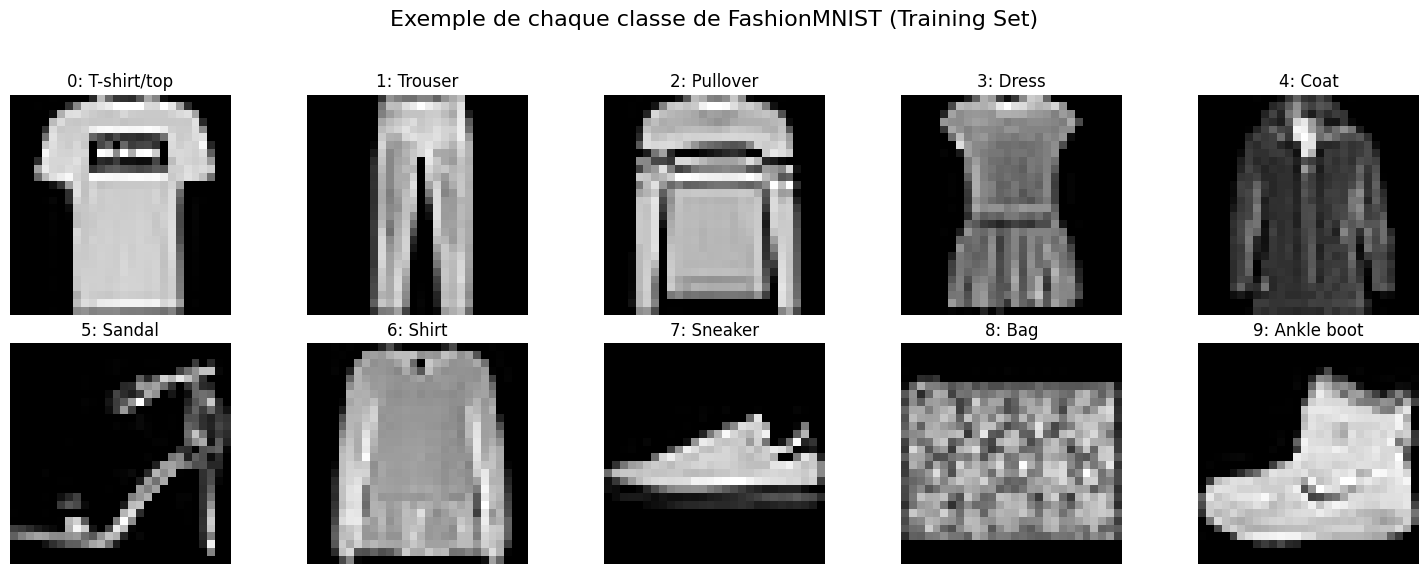

In [5]:
# Affichage d'une image par classe

targets = train_dataset.targets.numpy()
class_indices = {} 
num_classes = len(class_names)

for i in range(num_classes):
    first_index = np.where(targets == i)[0][0] 
    class_indices[i] = first_index


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    idx = class_indices[i]
    label = i
    
    image_tensor, _ = train_dataset[idx]
    

    
    image_display = image_tensor.clone()
    image_display = image_display.squeeze() 
    
    # Affichage
    ax.imshow(image_display.numpy(), cmap='gray')
    ax.set_title(f"{label}: {class_names[label]}")
    ax.axis('off')

plt.suptitle("Exemple de chaque classe de FashionMNIST (Training Set)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuster pour la suptitle
plt.show()

In [6]:
print("-" * 30)
print(f"Taille du jeu d'entraînement: {len(train_dataset)} images")
print(f"Taille du jeu test: {len(test_dataset)} images")
print(f"Taille d'une image: {image_display.shape}")

------------------------------
Taille du jeu d'entraînement: 60000 images
Taille du jeu test: 10000 images
Taille d'une image: torch.Size([28, 28])


### Comptes des classes (Train) ###
Classe 0 (T-shirt/top): 6000
Classe 1 (Trouser): 6000
Classe 2 (Pullover): 6000
Classe 3 (Dress): 6000
Classe 4 (Coat): 6000
Classe 5 (Sandal): 6000
Classe 6 (Shirt): 6000
Classe 7 (Sneaker): 6000
Classe 8 (Bag): 6000
Classe 9 (Ankle boot): 6000

### Comptes des classes (Test) ###
Classe 0 (T-shirt/top): 1000
Classe 1 (Trouser): 1000
Classe 2 (Pullover): 1000
Classe 3 (Dress): 1000
Classe 4 (Coat): 1000
Classe 5 (Sandal): 1000
Classe 6 (Shirt): 1000
Classe 7 (Sneaker): 1000
Classe 8 (Bag): 1000
Classe 9 (Ankle boot): 1000


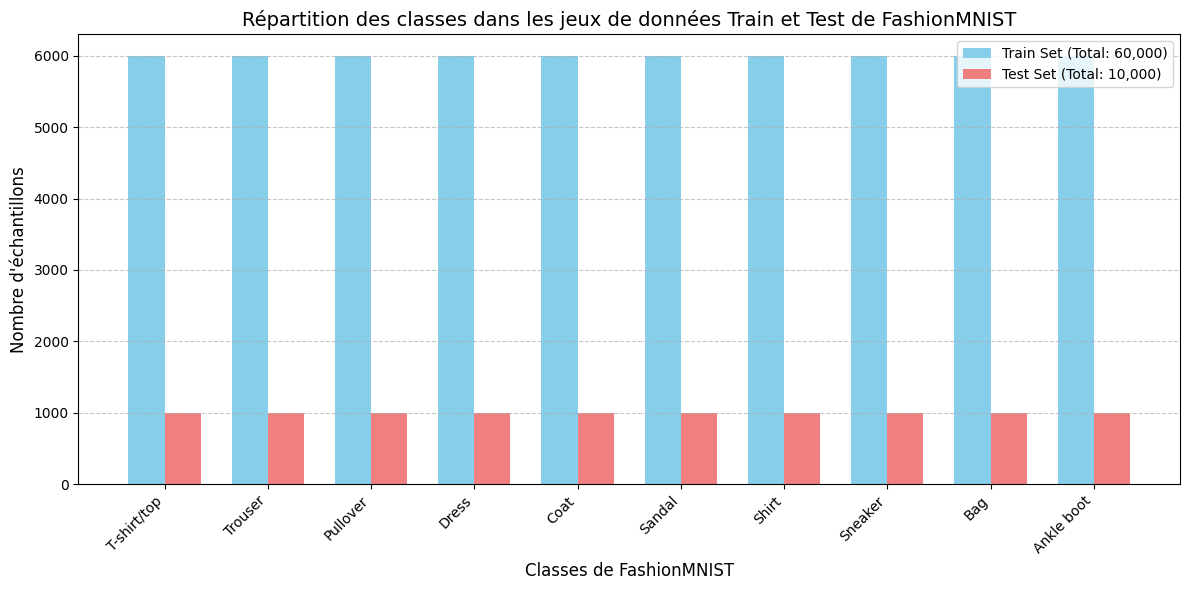

In [7]:
train_targets = train_dataset.targets.numpy()
test_targets = test_dataset.targets.numpy()


# --- 2. Comptage des classes (répartition réelle) ---
# np.unique(..., return_counts=True) retourne un tuple (labels uniques, comptes)
train_classes, train_counts = np.unique(train_targets, return_counts=True)
test_classes, test_counts = np.unique(test_targets, return_counts=True)

print("### Comptes des classes (Train) ###")
for label, count in zip(train_classes, train_counts):
    print(f"Classe {label} ({class_names[label]}): {count}")

print("\n### Comptes des classes (Test) ###")
for label, count in zip(test_classes, test_counts):
    print(f"Classe {label} ({class_names[label]}): {count}")


num_classes = len(class_names)
x = np.arange(num_classes) 
width = 0.35 

fig, ax = plt.subplots(figsize=(12, 6))


rects1 = ax.bar(x - width/2, train_counts, width, 
                label=f'Train Set (Total: {np.sum(train_counts):,})', 
                color='skyblue')


rects2 = ax.bar(x + width/2, test_counts, width, 
                label=f'Test Set (Total: {np.sum(test_counts):,})', 
                color='lightcoral')


ax.set_ylabel("Nombre d\'échantillons", fontsize=12)
ax.set_xlabel('Classes de FashionMNIST', fontsize=12)
ax.set_title('Répartition des classes dans les jeux de données Train et Test de FashionMNIST', fontsize=14)


ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<div id="chap1"></div>
<h2 style="color:#2980b9; font-size:32px; font-family:'Trebuchet MS', sans-serif; margin-top:30px;">
    1. What's a CVAE and what's the difference with a classic VAE?
</h2>

**Ressources** : https://www.youtube.com/watch?v=e4izCK7l4Kc , https://ijdykeman.github.io/ml/2016/12/21/cvae.html, https://medium.com/data-science/understanding-conditional-variational-autoencoders-cd62b4f57bf8

Kihyuk Sohn et al, 2015 :https://papers.nips.cc/paper_files/paper/2015/hash/8d55a249e6baa5c06772297520da2051-Abstract.html

As we have seen in class, Variationnal Autoencoders (VAE) is a unsupervised method that allow us to generate new data. The encoder is encoding the inputs in a latent space that is not single values but probability distributions, specifically gaussian distributions $\mathcal{N}(\mu,\sigma^2)$. During the learning phase, the encoder is learning the parameters of each gaussian distribution (one per latent component) that are independent and the decoder will learn how to reconstruct an output based on samples of those distributions.
Then, we can draw samples from these gaussian distributions and feed them to the decoder that will generate new unseen data.

A main advantage of VAEs is that they do not require labels to generate data (unsupervised method). However, this also means we cannot control attributes of the generated samples. For example, if you have a small labeled dataset and want to augment it for training a classifier, uncontrolled sampling may produce many examples of one class and bias the augmented dataset.


Hopefully, a model exists to solve this issue: Conditional Variationnall Autoencoders (CVAE).

The architecture of a CVAE is approximately the same as a VAE except that we are feeding the encoder and decoder part with the label.

For the example of images, the input is $(H,W,3)$ so we need to transform the one-hot encoding of the label $(N_{label},)$ to a $(H,W,1)$ shape. To do that, we use a *Dense* layer and reshape its output to get an image representation of the label. Then we concatenate both inputs to get the encoder input that here will be of shape $(H,W,4)$. For the decoder, the latent space is of shape $(latent_{dim},)$ so we simply concatenate the one-hot encoding representation of the label with the latent representation to get a decoder input of shape $(latent_{dim} + N_{label},)$.

Training is similar to a VAE. The loss function has two terms: a reconstruction term and a regularization term. The reconstruction term (e.g., binary cross-entropy or MSE, depending on the task) applies between the input and the reconstruction made by the autoencoder. The regularizer part is the Kullback-Leibler divergence between the encoder distribution $\mathcal{N}(\mu,\Sigma)$ (typically $\Sigma$ diagonal) and the true prior distribution usually assumed to be $\mathcal{N}(\mu,I)$. The difference with the loss used for VAE is that the encoder distribution is conditioned on the label $y$ as well as the image input $x$.

After the training is done, we have the parameters of the gaussian distribution. We can draw a sample of this distribution and tell the decoder for which label we want a new observation (by concatenating the one-hot encoding of the label to the sample) and feed the decoder with it. TADA, we have a new unseen observation of the label we specified. 
This will allow us to create exactly the same number of new observations for each label and get a bigger labeled dataset but still balanced. Note that the model is no longer strictly unsupervised (it uses labels during training), but it enables controlled data generation.

<div id="chap2"></div>
<h2 style="color:#2980b9; font-size:32px; font-family:'Trebuchet MS', sans-serif; margin-top:30px;">
    2. Creation of a CVAE
</h2>

In [79]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=10, img_h=28,img_w=28, nb_class=10):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim
        self.img_h=img_h
        self.img_w=img_w
        self.nb_class=nb_class
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 14, 14)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32,64,kernel_size=4,stride=2,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64,128,kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # Fully connected layers for mean and log variance
        self.fc_mu = nn.Linear(128*4*4,latent_dim)
        self.fc_logvar = nn.Linear(128*4*4,latent_dim)

        self.fc_label_encode = nn.Linear(nb_class, img_h * img_w)

        self.fc_decode = nn.Linear(latent_dim+nb_class, 128 * 4 * 4)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1), 
            nn.Sigmoid(),
        )

        

        

    def encode(self, x, label):
        B = x.size(0)

        one_hot_label=F.one_hot(label, num_classes=self.nb_class).float()
        label_encoding = self.fc_label_encode(one_hot_label)
        label_encoding=F.relu(label_encoding)

        x=x.view(B, 1, self.img_h, self.img_w)
        label_encoding=label_encoding.view(B, 1, self.img_h, self.img_w)

        x=torch.cat([x,label_encoding],1)

        x = self.encoder(x)# Encode the input image
        x = x.view(B, -1) # Flatten the output of the convolutional layers# Flatten the output of the convolutional layers
        
        mu = self.fc_mu(x)# Apply the corresponding FC layer
        logvar = self.fc_logvar(x)# Apply the corresponding FC layer
        return mu, logvar
    

    def sample(self, mu, logvar):
        # Sample z from the Gaussian with the given mu and logvar
        # by using the reparameterization trick: z = mu + sigma * epsilon
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    
    def decode(self, z, label):
        
        one_hot_label=F.one_hot(label, num_classes=self.nb_class).float()
        if one_hot_label.dim() == 1:
            one_hot_label = one_hot_label.unsqueeze(0) # Passe de [10] à [1, 10]
        z_cond=torch.cat([z,one_hot_label],1)

        x = self.fc_decode(z_cond)
        x = x.view(-1, 128, 4, 4)  # Reshape to (128, 4, 4) for the decoder
        x = self.decoder(x)
        return x



    def forward(self,x,label):
        x = x.to(device)
        label = label.to(device)

        mu, logvar = self.encode(x,label)
        z = self.sample(mu, logvar)
        return self.decode(z,label), mu, logvar

<div id="chap2"></div>
<h2 style="color:#2980b9; font-size:32px; font-family:'Trebuchet MS', sans-serif; margin-top:30px;">
    2. Loss function
</h2>

In [80]:
def loss_function(recon_x, x, mu, logvar, beta=1):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + beta * KLD

<div id="chap3"></div>
<h2 style="color:#2980b9; font-size:32px; font-family:'Trebuchet MS', sans-serif; margin-top:30px;">
    3. Training of the CVAE
</h2>

In [ ]:
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

batch_size=128
latent_dim = 2
learning_rate = 1e-3
epochs = 30
beta = 1


cvae=CVAE(latent_dim=latent_dim)
cvae.to(device)
optimizer=torch.optim.Adam(cvae.parameters(),lr=learning_rate)


for epoch in range(1, epochs + 1):
    cvae.train()
    running_loss = 0.0
    for batch_idx, (data, label) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = cvae(data,label)
        # epsilon = 1e-6 
        # recon_batch = torch.clamp(recon_batch, epsilon, 1.0 - epsilon)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch {epoch}, Training loss: {epoch_loss:.4f}')

Epoch 1, Training loss: 268.4070


<div id="chap4"></div>
<h2 style="color:#2980b9; font-size:32px; font-family:'Trebuchet MS', sans-serif; margin-top:30px;">
    4. Sampling with a CVAE
</h2>

(28, 28)
(28, 28)


Text(0.5, 1.0, 'Recomstruction')

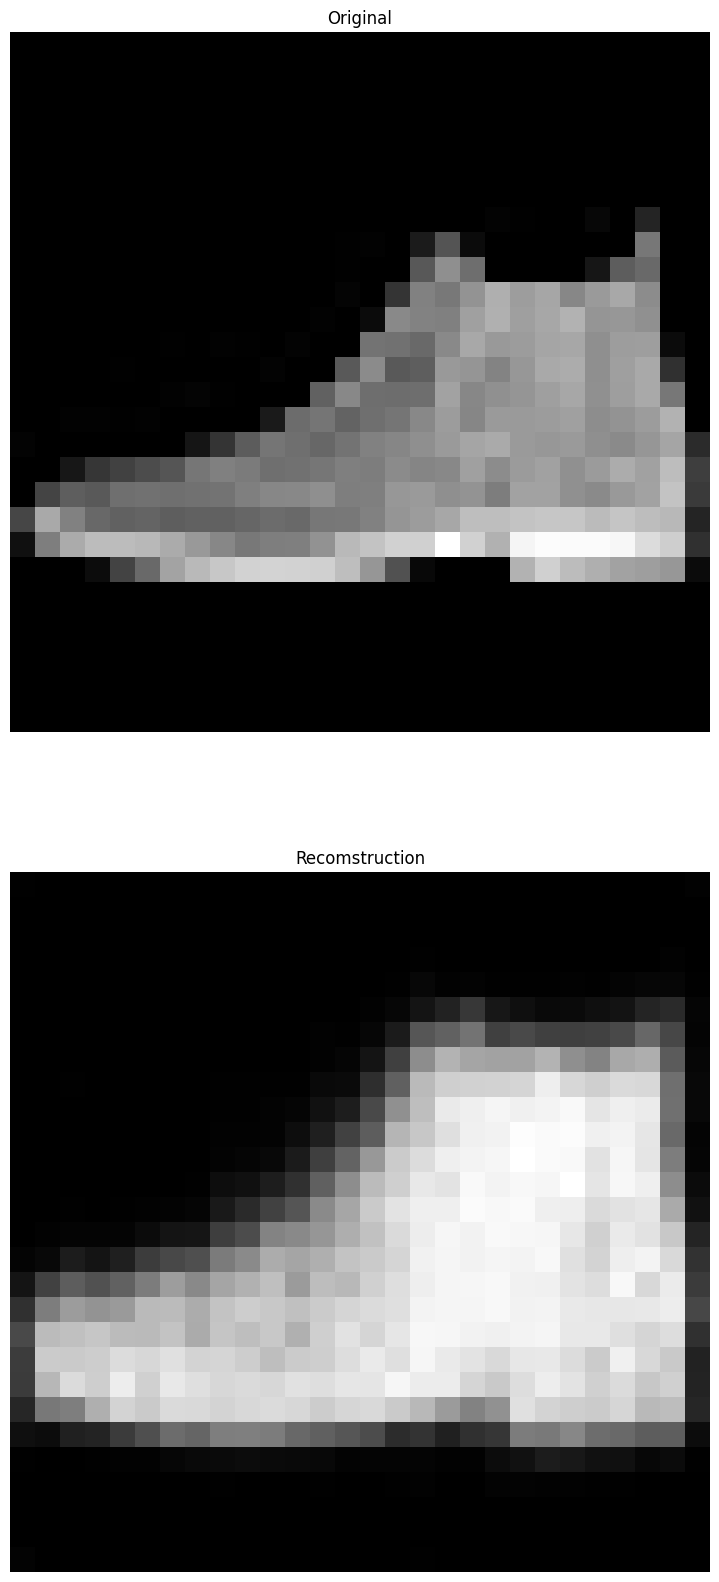

In [ ]:

random_images,labels = next(iter(test_loader))

recons, _, _ = cvae(random_images[0].to(device),labels[0].to(device))
# Reshape the images for plotting
random_images = random_images[0].cpu().numpy().squeeze()
recons = recons.detach().cpu().numpy().squeeze()
print(random_images.shape)
print(recons.shape)

fig, ax = plt.subplots(2, 1, figsize=(20, 20))
# Plot the original images and their reconstructions
ax[0].imshow(random_images, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Original')

        # Reconstructed images
ax[1].imshow(recons, cmap='gray')
ax[1].axis('off')
ax[1].set_title('Reconstruction')